In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
%matplotlib inline

## 1. Load & explore the data

In [6]:
import requests
from io import StringIO

# Check if the file exists. If not, download it.
# This makes the notebook more reproducible.
try:
    df = pd.read_csv("Mall_Customers.csv")
except FileNotFoundError:
    print("Mall_Customers.csv not found. Attempting to download from a public source...")
    url = "https://raw.githubusercontent.com/AnjulaMehto/MCA/master/Mall_Customers.csv"
    response = requests.get(url)
    response.raise_for_status() # Raise an exception for HTTP errors
    df = pd.read_csv(StringIO(response.text))
    print("Download complete.")

df.columns = ["CustomerID", "Gender", "Age", "AnnualIncome", "SpendingScore"]
print("Shape:", df.shape)
df.head(20)

Mall_Customers.csv not found. Attempting to download from a public source...
Download complete.
Shape: (200, 5)


,CustomerID,Gender,Age,AnnualIncome,SpendingScore
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [7]:
df.describe()

,CustomerID,Age,AnnualIncome,SpendingScore
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


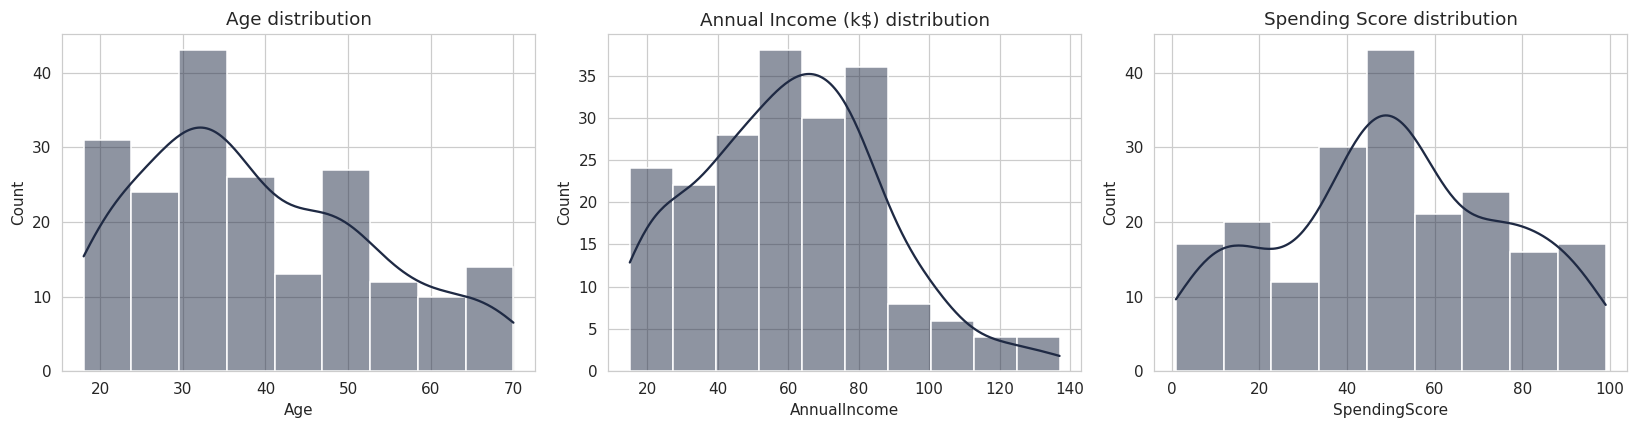

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df["Age"], kde=True, ax=axes[0], color="#1F2A44")
axes[0].set_title("Age distribution")
sns.histplot(df["AnnualIncome"], kde=True, ax=axes[1], color="#1F2A44")
axes[1].set_title("Annual Income (k$) distribution")
sns.histplot(df["SpendingScore"], kde=True, ax=axes[2], color="#1F2A44")
axes[2].set_title("Spending Score distribution")
plt.tight_layout()
plt.show()

The charts upside show the main metrics "Age distribution", "Annual Income distribution", "Spending Score distribution"

## 2. Customer segmentation with K-Means

Segmenting customers on Annual Income vs Spending Score.

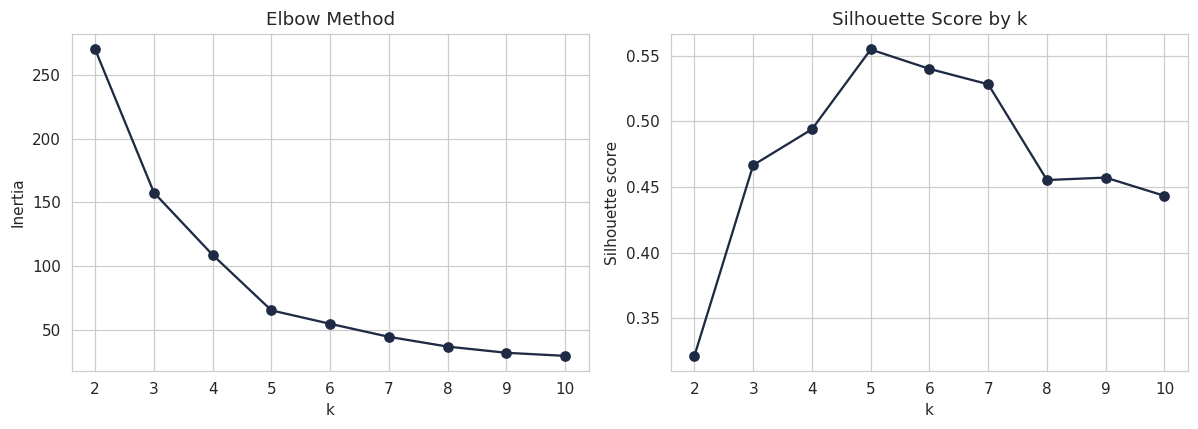

In [9]:
X_cluster = df[["AnnualIncome", "SpendingScore"]].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

inertias, sil_scores = [], []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list(K_range), inertias, marker="o", color="#1F2A44")
axes[0].set_title("Elbow Method"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[1].plot(list(K_range), sil_scores, marker="o", color="#1F2A44")
axes[1].set_title("Silhouette Score by k"); axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette score")
plt.tight_layout()
plt.show()

Both methods agree on k =5: the elbow flattens out around 5, and silhouette score peaks there (≈0.555).

Silhouette score: 0.555


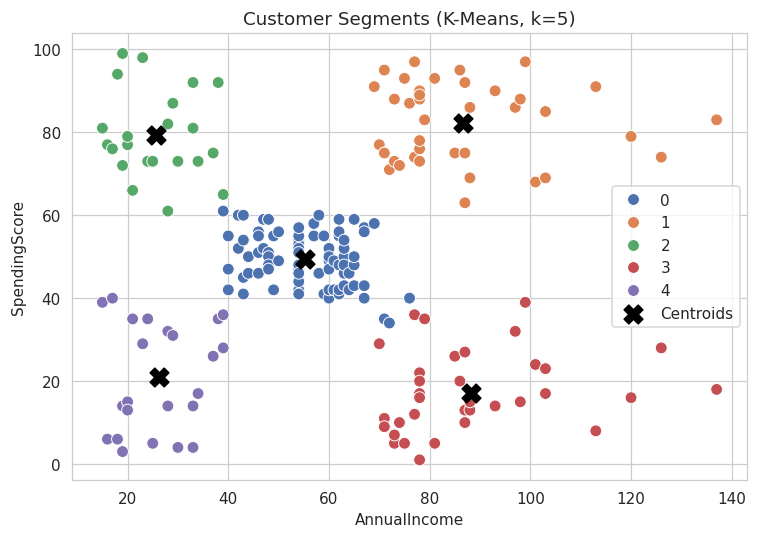

In [10]:
best_k = 5
km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["Cluster"] = km.fit_predict(X_scaled)
print(f"Silhouette score: {silhouette_score(X_scaled, df['Cluster']):.3f}")

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="AnnualIncome", y="SpendingScore", hue="Cluster", palette="deep", s=60)
centers = scaler.inverse_transform(km.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1], c="black", marker="X", s=150, label="Centroids")
plt.title("Customer Segments (K-Means, k=5)")
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
cluster_summary = df.groupby("Cluster")[["Age", "AnnualIncome", "SpendingScore"]].mean().round(1)
cluster_summary["Count"] = df.groupby("Cluster").size()
cluster_summary

,Age,AnnualIncome,SpendingScore,Count
Cluster,,,,
0,42.7,55.3,49.5,81
1,32.7,86.5,82.1,39
2,25.3,25.7,79.4,22
3,41.1,88.2,17.1,35
4,45.2,26.3,20.9,23


**Segment profiles:**

| Cluster | Profile |
|---|---|
| 0 | Mid income, average spenders (largest group) |
| 1 | High income, high spenders — **target segment !!!** |
| 2 | Low income, high spenders — young, impulsive |
| 3 | High income, low spenders — price-insensitive but disengaged |
| 4 | Low income, low spenders |


## 3. Regression: predicting Spending Score from Age & Income

Building a linear regression model and running full diagnostics: R², p-values, VIF (multicollinearity), and residual analysis.

In [12]:
X = df[["Age", "AnnualIncome"]]
y = df["SpendingScore"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print(f"R^2 (test): {r2_score(y_test, y_pred):.3f}")
print(f"MAE (test): {mean_absolute_error(y_test, y_pred):.2f}")
print("Coefficients:", dict(zip(X.columns, lr.coef_)))

R^2 (test): 0.020
MAE (test): 18.23
Coefficients: {'Age': np.float64(-0.5892919303966214), 'AnnualIncome': np.float64(0.05235826813645834)}


In [18]:
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data

,feature,VIF
0,Age,3.89824
1,AnnualIncome,3.89824


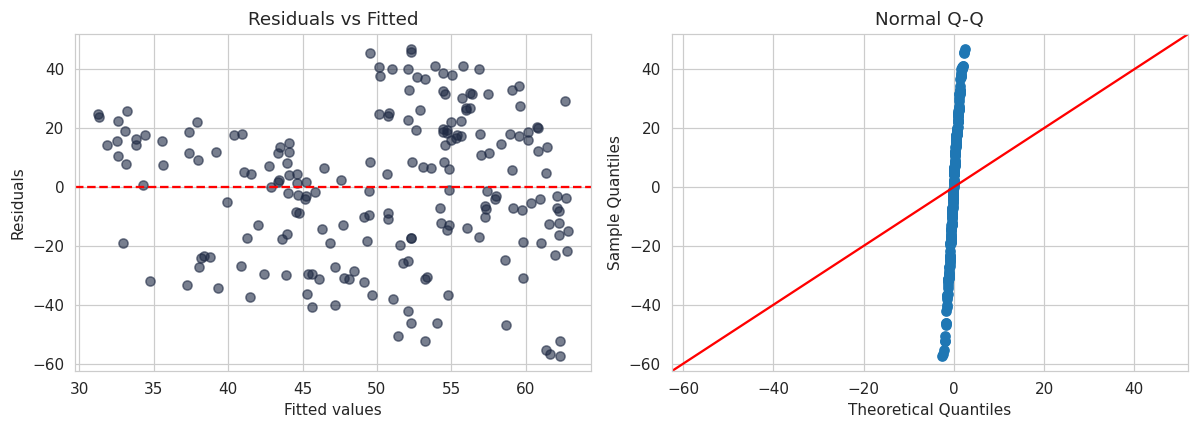

In [19]:
residuals = ols_model.resid
fitted = ols_model.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(fitted, residuals, alpha=0.6, color="#1F2A44")
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Fitted values"); axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted")

sm.qqplot(residuals, line="45", ax=axes[1])
axes[1].set_title("Normal Q-Q")
plt.tight_layout()
plt.show()

## 4. Conclusions

- **Clustering (k=5)** produced clean, well-separated, business-interpretable customer segments silhouette score 0.555.
- **Regression** had weak explanatory power (R² ≈ 0.11 full sample, 0.02 on test set). Age was a significant predictor (p < 0.001), but AnnualIncome was not (p = 0.93) as a *linear* predictor of spending score. VIF ≈ 1.0, so multicollinearity is not the issue.


 **Key takeaway:** income alone does not linearly predict spending behavior. This is exactly why the unsupervised clustering approach is more useful here than a single regression line it surfaces segments (e.g. low income/high spenders, high income/low spenders) that a linear model completely misses.
